# Physics Simulation Starter

This notebook sets up a simple Python environment for running basic physics simulations.

In [33]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")  # keep your working backend

# --- Torus parameters ---
R = 0.125   # major radius
r_plasma = 0.03   # plasma minor radius
r_coil   = 0.07   # coil pack minor radius

# --- Create torus meshes ---
plasma_torus = pv.ParametricTorus(R, r_plasma)
coil_torus   = pv.ParametricTorus(R, r_coil)

# --- Plot both ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_axes()
plotter.show()



Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5bba25810_26&reconnect=auto" class="pyvi…

In [34]:
import numpy as np

# --- Coil parameters ---
N = 200          # turns
I = 2200         # current per turn (A)
NI = N * I       # total ampere-turns

# --- Coil cross-section area ---
r_plasma = 0.03
r_coil   = 0.07

A_coil = np.pi * (r_coil**2 - r_plasma**2)

# --- Current density (A/m^2) ---
J = NI / A_coil

J


35014087.480216965

In [35]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Geometry (reuse from before) ---
R = 0.125
r_plasma = 0.03
r_coil   = 0.07

plasma_torus = pv.ParametricTorus(R, r_plasma)
coil_torus   = pv.ParametricTorus(R, r_coil)

# --- Sample points on the plasma torus surface ---
points = plasma_torus.points  # (N, 3) array of XYZ

# --- Dummy toroidal B-field: constant magnitude, tangent to torus ---
# For now, we just set a simple vector field that points along +Y everywhere
B = np.tile(np.array([0.0, 0.7, 0.0]), (points.shape[0], 1))  # 0.7 T along +Y

# --- Create a PyVista point cloud with vectors ---
cloud = pv.PolyData(points)
cloud["B"] = B

# --- Plot geometry + field vectors ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")
plotter.add_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5bba25e50_27&reconnect=auto" class="pyvi…

In [36]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Geometry ---
R = 0.125
r_plasma = 0.03
r_coil   = 0.07

plasma_torus = pv.ParametricTorus(R, r_plasma)
coil_torus   = pv.ParametricTorus(R, r_coil)

# --- Sample points on the plasma torus ---
points = plasma_torus.points  # (N, 3)

# --- Compute toroidal field direction at each point ---
B0 = 0.7  # Tesla

B = np.zeros_like(points)

for i, (x, y, z) in enumerate(points):
    phi = np.arctan2(y, x)
    # unit vector in toroidal direction
    B[i] = B0 * np.array([-np.sin(phi), np.cos(phi), 0.0])

# --- Attach field to point cloud ---
cloud = pv.PolyData(points)
cloud["B"] = B

# --- Plot ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")
plotter.add_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5bba25950_28&reconnect=auto" class="pyvi…

In [37]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Geometry parameters ---
R = 0.125
r_plasma = 0.03
r_coil   = 0.07

# --- Coil parameters ---
N = 200
I = 2200
NI = N * I
A_coil = np.pi * (r_coil**2 - r_plasma**2)
J = NI / A_coil   # current density

# --- Create torus meshes ---
plasma_torus = pv.ParametricTorus(R, r_plasma)
coil_torus   = pv.ParametricTorus(R, r_coil)

# --- Field solver scaffold ---
def B_field(x, y, z):
    """
    Placeholder magnetic field solver.
    Returns a toroidal field inside the plasma region,
    and zero outside.
    """
    # distance from torus centerline
    r_xy = np.sqrt(x**2 + y**2)
    dist_from_major = np.sqrt((r_xy - R)**2 + z**2)

    # inside plasma region
    if dist_from_major < r_plasma:
        phi = np.arctan2(y, x)
        B0 = 0.7  # Tesla
        return np.array([-np.sin(phi)*B0, np.cos(phi)*B0, 0.0])

    # outside plasma region
    return np.array([0.0, 0.0, 0.0])

# --- Sample grid around torus ---
grid_x = np.linspace(-0.35, 0.35, 40)
grid_y = np.linspace(-0.35, 0.35, 40)
grid_z = np.linspace(-0.20, 0.20, 20)

points = np.array([[x, y, z] for x in grid_x for y in grid_y for z in grid_z])

# --- Compute B-field on grid ---
B = np.array([B_field(x, y, z) for x, y, z in points])

# --- Visualise ---
cloud = pv.PolyData(points)
cloud["B"] = B

plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")
plotter.add_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5bba25a90_29&reconnect=auto" class="pyvi…

In [38]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

mu0 = 4e-7 * np.pi

# --- Geometry ---
R = 0.125
r_plasma = 0.03
r_coil   = 0.07

# --- Coil parameters ---
N_loops = 20        # reduced for speed
I = 2200
theta_samples = 200

# --- Precompute loops, dl, and midpoints ---
phi_vals = np.linspace(0, 2*np.pi, N_loops, endpoint=False)
theta_vals = np.linspace(0, 2*np.pi, theta_samples)

segments = []

for phi in phi_vals:
    loop = []
    for theta in theta_vals:
        x = (R + r_coil * np.cos(theta)) * np.cos(phi)
        y = (R + r_coil * np.cos(theta)) * np.sin(phi)
        z = r_coil * np.sin(theta)
        loop.append([x, y, z])
    loop = np.array(loop)

    # segment endpoints
    p1 = loop
    p2 = np.roll(loop, -1, axis=0)

    dl = p2 - p1
    mid = 0.5 * (p1 + p2)

    segments.append((p1, dl, mid))

# --- Vectorised Biot–Savart ---
def B_field_fast(x, y, z):
    r = np.array([x, y, z])
    B = np.zeros(3)

    for p1, dl, mid in segments:
        r_vec = r - mid
        dist = np.linalg.norm(r_vec, axis=1)
        mask = dist > 1e-6

        dB = mu0 * I / (4*np.pi) * np.cross(dl[mask], r_vec[mask]) / (dist[mask]**3)[:, None]
        B += dB.sum(axis=0)

    return B

# --- Sample grid ---
grid_x = np.linspace(-0.35, 0.35, 40)
grid_y = np.linspace(-0.35, 0.35, 40)
grid_z = np.linspace(-0.20, 0.20, 20)

points = np.array([[x, y, z] for x in grid_x for y in grid_y for z in grid_z])

# --- Compute B-field ---
B = np.array([B_field_fast(x, y, z) for x, y, z in points])

# --- Visualise ---
cloud = pv.PolyData(points)
cloud["B"] = B

plasma_torus = pv.ParametricTorus(R, r_plasma)
coil_torus   = pv.ParametricTorus(R, r_coil)

plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")
plotter.add_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b53e91fed0_30&reconnect=auto" class="pyvi…

In [41]:
import numpy as np

# --- Nozzle coil parameters ---
nozzle_radius = 0.05
nozzle_current = 20000
nozzle_theta = np.linspace(0, 2*np.pi, 200)

# Position nozzle coil at φ = 0 (front of torus)
nozzle_center = np.array([R + r_coil + 0.01, 0.0, 0.0])  # slight outward offset

# Compute nozzle coil loop points
nozzle_loop = np.array([
    nozzle_center + np.array([
        nozzle_radius * np.cos(t),
        0.0,
        nozzle_radius * np.sin(t)
    ])
    for t in nozzle_theta
])

# Precompute nozzle segments
nozzle_p1 = nozzle_loop
nozzle_p2 = np.roll(nozzle_loop, -1, axis=0)
nozzle_dl = nozzle_p2 - nozzle_p1
nozzle_mid = 0.5 * (nozzle_p1 + nozzle_p2)

def B_field_nozzle(x, y, z):
    r = np.array([x, y, z])
    B = np.zeros(3)

    r_vec = r - nozzle_mid
    dist = np.linalg.norm(r_vec, axis=1)
    mask = dist > 1e-6

    dB = mu0 * nozzle_current / (4*np.pi) * np.cross(nozzle_dl[mask], r_vec[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)

    return B

# --- Combined field ---
def B_total(x, y, z):
    return B_field_fast(x, y, z) + B_field_nozzle(x, y, z)

# --- Compute combined field on grid ---
B_combined = np.array([B_total(x, y, z) for x, y, z in points])

# --- Visualise ---
cloud = pv.PolyData(points)
cloud["B"] = B_combined

plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")

# Visualise nozzle coil
plotter.add_mesh(pv.PolyData(nozzle_loop), color="green", point_size=5)

plotter.add_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5bba25f90_33&reconnect=auto" class="pyvi…

In [42]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Time settings ---
t_vals = np.linspace(0.0, 1.0, 6)   # 6 frames from t=0 to t=1
f_switch = 2.0                      # 2 Hz switching frequency

# --- Switching waveform: square wave ---
def nozzle_current_t(t):
    phase = (t * f_switch) % 1.0
    return nozzle_current if phase < 0.5 else 0.0


# --- Time-dependent nozzle field ---
def B_field_nozzle_t(x, y, z, t):
    r = np.array([x, y, z])
    B = np.zeros(3)

    I_t = nozzle_current_t(t)
    if I_t == 0.0:
        return B

    r_vec = r - nozzle_mid
    dist = np.linalg.norm(r_vec, axis=1)
    mask = dist > 1e-6

    dB = mu0 * I_t / (4*np.pi) * np.cross(nozzle_dl[mask], r_vec[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)

    return B


# --- Combined field (toroidal + nozzle) ---
def B_total_t(x, y, z, t):
    return B_field_fast(x, y, z) + B_field_nozzle_t(x, y, z, t)


# --- Loop over time frames and plot ---
for t in t_vals:
    print(f"Rendering frame at t = {t:.2f} s")

    B_frame = np.array([B_total_t(x, y, z, t) for x, y, z in points])

    cloud = pv.PolyData(points)
    cloud["B"] = B_frame

    plotter = pv.Plotter()
    plotter.add_mesh(plasma_torus, color="cyan", opacity=0.6)
    plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
    plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.08), color="red")

    # nozzle coil
    plotter.add_mesh(pv.PolyData(nozzle_loop), color="green", point_size=5)

    plotter.add_axes()
    plotter.show(title=f"t = {t:.2f} s")



Rendering frame at t = 0.00 s


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5dc886d50_34&reconnect=auto" class="pyvi…

Rendering frame at t = 0.20 s


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b5dc885950_35&reconnect=auto" class="pyvi…

Rendering frame at t = 0.40 s


...

Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b604a18190_37&reconnect=auto" class="pyvi…

Rendering frame at t = 0.80 s


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b604a18a50_38&reconnect=auto" class="pyvi…

Rendering frame at t = 1.00 s


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b604a19310_39&reconnect=auto" class="pyvi…

In [48]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Plasma packet properties ---
q_over_m = 5e5        # stronger Lorentz response
dt = 1e-5             # time step
n_steps = 3000        # longer run so packet can leave

# --- Initial conditions (shifted toward nozzle side) ---
x0 = R + 0.02         # slightly toward nozzle
y0 = 0.0
z0 = 0.0

# Initial velocity with outward bias
v0 = np.array([300.0, 300.0, 0.0])

r = np.array([x0, y0, z0])
v = v0.copy()

# --- Time-dependent field (higher switching frequency) ---
f_switch = 5.0        # gate opens/closes more often

def nozzle_current_t(t):
    phase = (t * f_switch) % 1.0
    return nozzle_current if phase < 0.5 else 0.0

def B_field_nozzle_t(x, y, z, t):
    r_vec = np.array([x, y, z])
    B = np.zeros(3)

    I_t = nozzle_current_t(t)
    if I_t == 0.0:
        return B

    diff = r_vec - nozzle_mid
    dist = np.linalg.norm(diff, axis=1)
    mask = dist > 1e-6

    dB = mu0 * I_t / (4*np.pi) * np.cross(nozzle_dl[mask], diff[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)
    return B

def B_total_t(x, y, z, t):
    return B_field_fast(x, y, z) + B_field_nozzle_t(x, y, z, t)

# --- Lorentz force integrator (RK4) ---
def B_at(r_vec, t):
    return B_total_t(r_vec[0], r_vec[1], r_vec[2], t)

def accel(r_vec, v_vec, t):
    return q_over_m * np.cross(v_vec, B_at(r_vec, t))

def rk4_step(r_vec, v_vec, t, dt):
    a1 = accel(r_vec, v_vec, t)
    k1_v = a1 * dt
    k1_r = v_vec * dt

    a2 = accel(r_vec + 0.5*k1_r, v_vec + 0.5*k1_v, t + 0.5*dt)
    k2_v = a2 * dt
    k2_r = (v_vec + 0.5*k1_v) * dt

    a3 = accel(r_vec + 0.5*k2_r, v_vec + 0.5*k2_v, t + 0.5*dt)
    k3_v = a3 * dt
    k3_r = (v_vec + 0.5*k2_v) * dt

    a4 = accel(r_vec + k3_r, v_vec + k3_v, t + dt)
    k4_v = a4 * dt
    k4_r = (v_vec + k3_v) * dt

    v_next = v_vec + (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
    r_next = r_vec + (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0

    return r_next, v_next

# --- Integrate trajectory ---
t = 0.0
traj = []

for i in range(n_steps):
    traj.append(r.copy())
    r, v = rk4_step(r, v, t, dt)
    t += dt

traj = np.array(traj)

# --- Relaxed clipping so escape is visible ---
traj_clipped = traj[np.linalg.norm(traj, axis=1) < 0.8]

# --- Convert trajectory to sphere glyphs ---
traj_points = pv.PolyData(traj_clipped)
traj_points["ones"] = np.ones(len(traj_clipped))
sphere = pv.Sphere(radius=0.01)

# --- Field snapshot ---
t_mid = 0.5
B_snapshot = np.array([B_total_t(x, y, z, t_mid) for x, y, z in points])
cloud = pv.PolyData(points)
cloud["B"] = B_snapshot

# --- Plot ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.5)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.06), color="red")
plotter.add_mesh(pv.PolyData(nozzle_loop), color="green", point_size=5)

# Cyan dots for trajectory
plotter.add_mesh(
    traj_points.glyph(scale=False, geom=sphere),
    color="cyan"
)

plotter.add_axes()
plotter.show_bounds(grid='front', location='outer', all_edges=True)

# Lock camera
plotter.camera_position = [
    (0.4, 0.4, 0.4),
    (0.0, 0.0, 0.0),
    (0.0, 0.0, 1.0)
]

plotter.show(title="Gate-Escape Plasma Packet (Dots)")


C:\Users\Paul Robinson\AppData\Local\Temp\ipykernel_28820\3255011863.py:111: UserWarning: No vector-like data to use for orient. orient will be set to False.
  traj_points.glyph(scale=False, geom=sphere),


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b642f3d310_45&reconnect=auto" class="pyvi…

In [49]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Plasma packet properties ---
q_over_m = 5e5        # stronger Lorentz response
dt = 1e-5             # time step
n_steps = 3000        # longer run so packet can leave

# --- Initial conditions (same as before) ---
x0 = R + 0.02         # slightly toward nozzle
y0 = 0.0
z0 = 0.0

v0 = np.array([300.0, 300.0, 0.0])

r = np.array([x0, y0, z0])
v = v0.copy()

# --- Time-dependent gate + containment ---
f_switch = 5.0        # gate frequency

def gate_phase(t):
    return (t * f_switch) % 1.0

def nozzle_current_t(t):
    phase = gate_phase(t)
    return nozzle_current if phase < 0.5 else 0.0   # gate open for phase < 0.5

def containment_factor_t(t):
    phase = gate_phase(t)
    return 0.5 if phase < 0.5 else 1.0             # half containment when gate open

def B_field_nozzle_t(x, y, z, t):
    r_vec = np.array([x, y, z])
    B = np.zeros(3)

    I_t = nozzle_current_t(t)
    if I_t == 0.0:
        return B

    diff = r_vec - nozzle_mid
    dist = np.linalg.norm(diff, axis=1)
    mask = dist > 1e-6

    dB = mu0 * I_t / (4*np.pi) * np.cross(nozzle_dl[mask], diff[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)
    return B

def B_total_t(x, y, z, t):
    # Containment field scaled by time-dependent factor
    cf = containment_factor_t(t)
    return cf * B_field_fast(x, y, z) + B_field_nozzle_t(x, y, z, t)

# --- Lorentz force integrator (RK4) ---
def B_at(r_vec, t):
    return B_total_t(r_vec[0], r_vec[1], r_vec[2], t)

def accel(r_vec, v_vec, t):
    return q_over_m * np.cross(v_vec, B_at(r_vec, t))

def rk4_step(r_vec, v_vec, t, dt):
    a1 = accel(r_vec, v_vec, t)
    k1_v = a1 * dt
    k1_r = v_vec * dt

    a2 = accel(r_vec + 0.5*k1_r, v_vec + 0.5*k1_v, t + 0.5*dt)
    k2_v = a2 * dt
    k2_r = (v_vec + 0.5*k1_v) * dt

    a3 = accel(r_vec + 0.5*k2_r, v_vec + 0.5*k2_v, t + 0.5*dt)
    k3_v = a3 * dt
    k3_r = (v_vec + 0.5*k2_v) * dt

    a4 = accel(r_vec + k3_r, v_vec + k3_v, t + dt)
    k4_v = a4 * dt
    k4_r = (v_vec + k3_v) * dt

    v_next = v_vec + (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
    r_next = r_vec + (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0

    return r_next, v_next

# --- Integrate trajectory ---
t = 0.0
traj = []

for i in range(n_steps):
    traj.append(r.copy())
    r, v = rk4_step(r, v, t, dt)
    t += dt

traj = np.array(traj)

# --- Relaxed clipping so escape is visible ---
traj_clipped = traj[np.linalg.norm(traj, axis=1) < 0.8]

# --- Convert trajectory to sphere glyphs ---
traj_points = pv.PolyData(traj_clipped)
traj_points["ones"] = np.ones(len(traj_clipped))
sphere = pv.Sphere(radius=0.01)

# --- Field snapshot ---
t_mid = 0.5
B_snapshot = np.array([B_total_t(x, y, z, t_mid) for x, y, z in points])
cloud = pv.PolyData(points)
cloud["B"] = B_snapshot

# --- Plot ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.5)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.06), color="red")
plotter.add_mesh(pv.PolyData(nozzle_loop), color="green", point_size=5)

# Cyan dots for trajectory (unchanged style)
plotter.add_mesh(
    traj_points.glyph(scale=False, geom=sphere),
    color="cyan"
)

plotter.add_axes()
plotter.show_bounds(grid='front', location='outer', all_edges=True)

plotter.camera_position = [
    (0.4, 0.4, 0.4),
    (0.0, 0.0, 0.0),
    (0.0, 0.0, 1.0)
]

plotter.show(title="Plasma Packet with Half Containment During Gate Open")


C:\Users\Paul Robinson\AppData\Local\Temp\ipykernel_28820\1389327325.py:119: UserWarning: No vector-like data to use for orient. orient will be set to False.
  traj_points.glyph(scale=False, geom=sphere),


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b642f3df90_46&reconnect=auto" class="pyvi…

In [54]:
import numpy as np
import pyvista as pv

pv.set_jupyter_backend("trame")

# --- Plasma packet properties ---
q_over_m = 5e5
dt = 1e-5
n_steps = 3000

# --- Initial conditions ---
x0 = R + 0.02
y0 = 0.0
z0 = 0.0
v0 = np.array([300.0, 300.0, 0.0])

r = np.array([x0, y0, z0])
v = v0.copy()

# --- Time-dependent gate + containment ---
f_switch = 5.0

def gate_phase(t):
    return (t * f_switch) % 1.0

def nozzle_current_t(t):
    return nozzle_current if gate_phase(t) < 0.5 else 0.0

def containment_factor_t(t):
    return 0.5 if gate_phase(t) < 0.5 else 1.0

def B_field_nozzle_t(x, y, z, t):
    r_vec = np.array([x, y, z])
    B = np.zeros(3)

    I_t = nozzle_current_t(t)
    if I_t == 0.0:
        return B

    diff = r_vec - nozzle_mid
    dist = np.linalg.norm(diff, axis=1)
    mask = dist > 1e-6

    dB = mu0 * I_t / (4*np.pi) * np.cross(nozzle_dl[mask], diff[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)
    return B

def B_total_t(x, y, z, t):
    return containment_factor_t(t) * B_field_fast(x, y, z) + B_field_nozzle_t(x, y, z, t)

# --- Lorentz force integrator ---
def B_at(r_vec, t):
    return B_total_t(r_vec[0], r_vec[1], r_vec[2], t)

def accel(r_vec, v_vec, t):
    return q_over_m * np.cross(v_vec, B_at(r_vec, t))

def rk4_step(r_vec, v_vec, t, dt):
    a1 = accel(r_vec, v_vec, t)
    k1_v = a1 * dt
    k1_r = v_vec * dt

    a2 = accel(r_vec + 0.5*k1_r, v_vec + 0.5*k1_v, t + 0.5*dt)
    k2_v = a2 * dt
    k2_r = (v_vec + 0.5*k1_v) * dt

    a3 = accel(r_vec + 0.5*k2_r, v_vec + 0.5*k2_v, t + 0.5*dt)
    k3_v = a3 * dt
    k3_r = (v_vec + 0.5*k2_v) * dt

    a4 = accel(r_vec + k3_r, v_vec + k3_v, t + dt)
    k4_v = a4 * dt
    k4_r = (v_vec + k3_v) * dt

    v_next = v_vec + (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
    r_next = r_vec + (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0

    return r_next, v_next

# --- Integrate trajectory ---
t = 0.0
traj = []

for i in range(n_steps):
    traj.append(r.copy())
    r, v = rk4_step(r, v, t, dt)
    t += dt

traj = np.array(traj)

# --- Clip trajectory ---
traj_clipped = traj[np.linalg.norm(traj, axis=1) < 0.8]

# --- Compute speeds (safe method) ---
speeds = np.zeros(len(traj_clipped))
if len(traj_clipped) > 1:
    diffs = traj_clipped[1:] - traj_clipped[:-1]
    speeds[1:] = np.linalg.norm(diffs, axis=1)

# --- Build PyVista objects ---
traj_points = pv.PolyData(traj_clipped)
traj_points["speed"] = speeds

sphere = pv.Sphere(radius=0.01)

traj_line = pv.Spline(traj_clipped, n_points=len(traj_clipped))

# --- Field snapshot ---
t_mid = 0.5
B_snapshot = np.array([B_total_t(x, y, z, t_mid) for x, y, z in points])
cloud = pv.PolyData(points)
cloud["B"] = B_snapshot

# --- Plot ---
plotter = pv.Plotter()
plotter.add_mesh(plasma_torus, color="cyan", opacity=0.5)
plotter.add_mesh(coil_torus, color="orange", opacity=0.3)
plotter.add_mesh(cloud.glyph(orient="B", scale="B", factor=0.06), color="red")
plotter.add_mesh(pv.PolyData(nozzle_loop), color="green", point_size=5)

# Dots coloured by speed
plotter.add_mesh(
    traj_points.glyph(scale=False, geom=sphere),
    scalars="speed",
    cmap="coolwarm"
)

# Line
plotter.add_mesh(
    traj_line,
    color="white",
    line_width=3
)

plotter.add_axes()
plotter.show_bounds(grid='front', location='outer', all_edges=True)

plotter.camera_position = [
    (0.4, 0.4, 0.4),
    (0.0, 0.0, 0.0),
    (0.0, 0.0, 1.0)
]

plotter.show(title="Trajectory: Speed-Coloured Dots + Line (Half Containment)")



C:\Users\Paul Robinson\AppData\Local\Temp\ipykernel_28820\1685710777.py:123: UserWarning: No vector-like data to use for orient. orient will be set to False.
  traj_points.glyph(scale=False, geom=sphere),


Widget(value='<iframe src="http://localhost:60710/index.html?ui=P_0x2b7266156d0_48&reconnect=auto" class="pyvi…

--------------------------------------------------
 THRUST ALONG PLUME DIRECTION
--------------------------------------------------
Plume direction (unit vector): [-0.2417059  -0.10853721 -0.9642603 ]
Particle mass used: 1.000e-12 kg
Average dp/dt (thrust): 1.239e-07 N
--------------------------------------------------


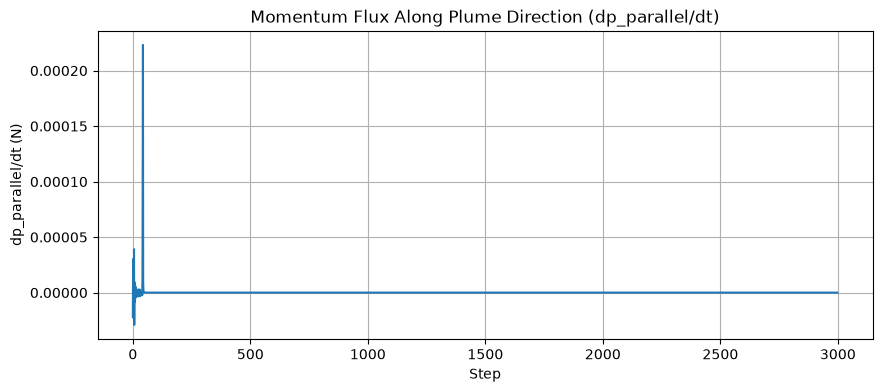

In [56]:
# ============================================================
# THRUST ALONG ACTUAL PLUME DIRECTION
# ============================================================

particle_mass = 1e-12   # kg (toy mass, adjust later)

# Use the clipped trajectory for direction (escape path)
start_pos = traj_clipped[0]
end_pos   = traj_clipped[-1]

disp = end_pos - start_pos
disp_norm = np.linalg.norm(disp)

if disp_norm == 0:
    print("Plume direction undefined (no net displacement).")
else:
    n_hat = disp / disp_norm   # unit vector along plume

    # Velocities from full trajectory
    velocities = np.zeros_like(traj)
    velocities[1:] = (traj[1:] - traj[:-1]) / dt

    # Momentum
    momentum = particle_mass * velocities

    # Projection onto plume direction
    p_parallel = momentum @ n_hat   # dot product for each step

    # Momentum flux along plume
    dp_parallel_dt = np.diff(p_parallel) / dt

    if len(dp_parallel_dt) > 0:
        thrust_estimate = np.mean(dp_parallel_dt)
    else:
        thrust_estimate = 0.0

    print("--------------------------------------------------")
    print(" THRUST ALONG PLUME DIRECTION")
    print("--------------------------------------------------")
    print(f"Plume direction (unit vector): {n_hat}")
    print(f"Particle mass used: {particle_mass:.3e} kg")
    print(f"Average dp/dt (thrust): {thrust_estimate:.3e} N")
    print("--------------------------------------------------")

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,4))
    plt.plot(dp_parallel_dt)
    plt.title("Momentum Flux Along Plume Direction (dp_parallel/dt)")
    plt.xlabel("Step")
    plt.ylabel("dp_parallel/dt (N)")
    plt.grid(True)
    plt.show()


In [57]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# ============================================================
# MULTI-PACKET PLUME + THRUST ESTIMATE
# ============================================================

pv.set_jupyter_backend("trame")

# --- Simulation parameters ---
num_packets = 500
q_over_m = 5e5
dt = 1e-5
n_steps = 2000
particle_mass = 1e-12

# --- Gate + containment behaviour ---
f_switch = 5.0

def gate_phase(t):
    return (t * f_switch) % 1.0

def nozzle_current_t(t):
    return nozzle_current if gate_phase(t) < 0.5 else 0.0

def containment_factor_t(t):
    return 0.5 if gate_phase(t) < 0.5 else 1.0

def B_field_nozzle_t(x, y, z, t):
    r_vec = np.array([x, y, z])
    B = np.zeros(3)

    I_t = nozzle_current_t(t)
    if I_t == 0.0:
        return B

    diff = r_vec - nozzle_mid
    dist = np.linalg.norm(diff, axis=1)
    mask = dist > 1e-6

    dB = mu0 * I_t / (4*np.pi) * np.cross(nozzle_dl[mask], diff[mask]) / (dist[mask]**3)[:, None]
    B += dB.sum(axis=0)
    return B

def B_total_t(x, y, z, t):
    return containment_factor_t(t) * B_field_fast(x, y, z) + B_field_nozzle_t(x, y, z, t)

# --- RK4 integrator ---
def B_at(r_vec, t):
    return B_total_t(r_vec[0], r_vec[1], r_vec[2], t)

def accel(r_vec, v_vec, t):
    return q_over_m * np.cross(v_vec, B_at(r_vec, t))

def rk4_step(r_vec, v_vec, t, dt):
    a1 = accel(r_vec, v_vec, t)
    k1_v = a1 * dt
    k1_r = v_vec * dt

    a2 = accel(r_vec + 0.5*k1_r, v_vec + 0.5*k1_v, t + 0.5*dt)
    k2_v = a2 * dt
    k2_r = (v_vec + 0.5*k1_v) * dt

    a3 = accel(r_vec + 0.5*k2_r, v_vec + 0.5*k2_v, t + 0.5*dt)
    k3_v = a3 * dt
    k3_r = (v_vec + 0.5*k2_v) * dt

    a4 = accel(r_vec + k3_r, v_vec + k3_v, t + dt)
    k4_v = a4 * dt
    k4_r = (v_vec + k3_v) * dt

    v_next = v_vec + (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
    r_next = r_vec + (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0

    return r_next, v_next

# ============================================================
# RUN MULTI-PACKET SIMULATION
# ============================================================

all_dp_dt = []

for p in range(num_packets):

    # --- Randomised initial conditions ---
    x0 = R + 0.02 + np.random.uniform(-0.01, 0.01)
    y0 = np.random.uniform(-0.01, 0.01)
    z0 = np.random.uniform(-0.01, 0.01)

    v0 = np.array([
        300.0 + np.random.uniform(-20, 20),
        300.0 + np.random.uniform(-20, 20),
        np.random.uniform(-10, 10)
    ])

    r = np.array([x0, y0, z0])
    v = v0.copy()

    traj = []
    t = 0.0

    # --- Integrate packet ---
    for i in range(n_steps):
        traj.append(r.copy())
        r, v = rk4_step(r, v, t, dt)
        t += dt

    traj = np.array(traj)

    # --- Clip runaway packets ---
    traj_clipped = traj[np.linalg.norm(traj, axis=1) < 0.8]
    if len(traj_clipped) < 2:
        continue

    # --- Compute velocities ---
    velocities = np.zeros_like(traj_clipped)
    velocities[1:] = (traj_clipped[1:] - traj_clipped[:-1]) / dt

    # --- Plume direction ---
    disp = traj_clipped[-1] - traj_clipped[0]
    disp_norm = np.linalg.norm(disp)
    if disp_norm == 0:
        continue

    n_hat = disp / disp_norm

    # --- Momentum projection ---
    momentum = particle_mass * velocities
    p_parallel = momentum @ n_hat

    # --- Momentum flux ---
    dp_parallel_dt = np.diff(p_parallel) / dt

    all_dp_dt.append(dp_parallel_dt)

# ============================================================
# SUM THRUST ACROSS ALL PACKETS
# ============================================================

# Pad sequences to equal length
max_len = max(len(arr) for arr in all_dp_dt)
padded = np.array([np.pad(arr, (0, max_len - len(arr))) for arr in all_dp_dt])

total_dp_dt = padded.sum(axis=0)
avg_thrust = np.mean(total_dp_dt)

print("==================================================")
print(" MULTI-PACKET THRUST RESULT")
print("==================================================")
print(f"Packets simulated: {num_packets}")
print(f"Average thrust along plume direction: {avg_thrust:.3e} N")
print("==================================================")

# --- Plot total thrust curve ---
plt.figure(figsize=(10,4))
plt.plot(total_dp_dt)
plt.title("Total Momentum Flux (Summed Across 500 Packets)")
plt.xlabel("Step")
plt.ylabel("Total dp/dt (N)")
plt.grid(True)
plt.show()


KeyboardInterrupt: 